# 2D Kernel with SPECFEM2D - Multiple Sources
By Andrea R.  
Utility functions written by Ridvan Orsvuran.  
Following file structure as in the Seisflows example (By Bryant Chow)

In [1]:
import os
import shutil
import matplotlib
import numpy as np
import FunctionsPlotBin
import matplotlib.pyplot as plt

from UtilityFunctions import read_trace, specfem2D_prep_save_forward, replace_line, save_trace, specfem2D_prep_adjoint, grid
from scipy.integrate import simps

# Domain: 
2D:   
x-dir = 4000 m   
z-dir = 4000 m   

### Source locations
Source #1:
x = 1000 m     
z = 2000 m

Source #2:
x = 2000 m
z = 2500 m  

### Output station location: 
Station #1 (AA)                             
x = 3000 m  
z = 2000 m  

### Boundary conditions 
Type: PML_BOUNDARY_CONDITIONS  
absorbbottom                    = true  
absorbright                     = true  
absorbtop                       = true  
absorbleft                      = true  

### Velocity model:

#### Initial model:  
Model: P (or PI) velocity min,max =    3000 m/s              
Model: S velocity min,max         =    1800 m/s        
Model: density min,max            =    2700 kg/m3           

#### True model (~1% perturbation of the Vs - initial model):   
Model: P (or PI) velocity min,max =    3000 m/s                
Model: S velocity min,max         =    1820 m/s          
Model: density min,max            =    2700 kg/m3

### Set Specfem2D and work directories 

In [2]:
specfem2d_path = "/home/masa/" # for desktop machine
#specfem2d_path = "/home/masan/" # for laptop 
EXAMPLE = os.path.join(os.getcwd(),"Examples", "DATA_Example01")
WORKDIR = os.path.join(os.getcwd(),"work")

# Incase we've run this docs page before, delete the working directory before remaking
if os.path.exists(WORKDIR):
    shutil.rmtree(WORKDIR)
os.makedirs(WORKDIR, exist_ok=True)

In [3]:
# Distribute the necessary file structure of the SPECFEM2D repository that we will reference
SPECFEM2D_ORIGINAL = os.path.join(specfem2d_path, "specfem2d") 
SPECFEM2D_BIN_ORIGINAL = os.path.join(SPECFEM2D_ORIGINAL, "bin")
SPECFEM2D_DATA_ORIGINAL = os.path.join(SPECFEM2D_ORIGINAL, "DATA")

# The SPECFEM2D working directory that we will create separate from the downloaded repo
SPECFEM2D_WORKDIR = os.path.join(WORKDIR, "ExampleKernelMultiSources")
SPECFEM2D_BIN = os.path.join(SPECFEM2D_WORKDIR, "bin")
SPECFEM2D_DATA = os.path.join(SPECFEM2D_WORKDIR, "DATA")
SPECFEM2D_OUTPUT = os.path.join(SPECFEM2D_WORKDIR, "OUTPUT_FILES")

# Pre-defined locations of velocity models we will generate using the solver
SPECFEM2D_MODEL_INIT = os.path.join(SPECFEM2D_WORKDIR, "OUTPUT_FILES_INIT")
SPECFEM2D_MODEL_TRUE = os.path.join(SPECFEM2D_WORKDIR, "OUTPUT_FILES_TRUE")

In [4]:
# Copy the binary files incase we update the source code. These can also be symlinked.
shutil.copytree(SPECFEM2D_BIN_ORIGINAL, SPECFEM2D_BIN)

# Copy the DATA/ directory
shutil.copytree(EXAMPLE, SPECFEM2D_DATA)
!pwd
!ls

/home/masa/FWI_MAH575/JupyterNotebooks
 A_InstallingSpecfem2d.ipynb		        Examples
 B_Specfem2D_Example.ipynb		        export.py
 C_Specfem2D_Tomofile.ipynb		        FunctionsPlotBin.py
 D_Specfem2D_Kernel.ipynb		        __pycache__
'D_Specfem2D_Kernel_MultiReceiver copy.ipynb'   README.md
 D_Specfem2D_Kernel_MultiReceiver.ipynb         SPECFEM2D_Analysis.ipynb
 D_Specfem2D_Kernel_MultiSources.ipynb	        UtilityFunctions.py
 D_Specfem2D_Kernel_P.ipynb		        work
 E_Specfem2D_ExampleLayeredModel.ipynb


In [5]:
# Create a new receiver  file with multiple receivers
receiver_content = """S0001    AA          3000.0000000        2000.0000000       0.0         0.0
"""

with open(os.path.join(SPECFEM2D_DATA, "RECEIVER"), "w") as f:
    f.write(receiver_content)

In [6]:
# Create a SOURCE file with multiple sources
source_content = """#Source1 
source_surf = .false.
xs = 1000.0
zs = 2000.0
source_type = 1
time_function_type = 1
name_of_source_file             = YYYYYYYY       # Only for option 8 : file containing the source wavelet
burst_band_width                = 0.    
f0 = 5.0
tshift = 0.0
anglesource = 0.
Mxx = 1.
Mzz = 1.
Mxz = 0.
factor = 1.0d10
vx                              = 0.0            # Horizontal source velocity (m/s)
vz                              = 0.0   

## Source 2
source_surf = .false.
xs = 2000.0
zs = 2500.0
source_type = 1
time_function_type = 1
name_of_source_file             = YYYYYYYY       # Only for option 8 : file containing the source wavelet
burst_band_width                = 0.    
f0 = 5.0
tshift = 3.0
anglesource = 0.
Mxx = 1.
Mzz = 1.
Mxz = 0.
factor = 1.0d10
vx                              = 0.0            # Horizontal source velocity (m/s)
vz                              = 0.0   
"""

with open(os.path.join(SPECFEM2D_DATA, "SOURCE"), "w") as f:
    f.write(source_content)

### Generate true model

In [7]:
os.chdir(SPECFEM2D_DATA)
specfem2D_prep_save_forward("Par_file")
# Modify the Par_file to increase Initial Vs by ~1% 
replace_line("Par_file",33,"P_SV                            = .false. \n")
# source parameters
replace_line("Par_file",110,'NSOURCES                        = 2       \n')
# receiver parameters
replace_line("Par_file",233,'STACEY_ABSORBING_CONDITIONS     = .false. \n')
replace_line("Par_file",262,'1 1 2700.d0 3000.d0 1820.d0 0 0 9999 9999 0 0 0 0 0 0 \n')
replace_line("Par_file",218,'PML_BOUNDARY_CONDITIONS         = .true. \n')
#replace_line("Par_file",303,'nx                              = 400             # number of elements along X \n')
#replace_line("Par_file",314,' 1 400  1 400 1 \n')

In [8]:
# create the OUTPUT_FILES directory before running 
os.chdir(SPECFEM2D_WORKDIR)
if os.path.exists(SPECFEM2D_OUTPUT):
    shutil.rmtree(SPECFEM2D_OUTPUT)
os.mkdir(SPECFEM2D_OUTPUT)
!ls

bin  DATA  OUTPUT_FILES


In [9]:
os.chdir(SPECFEM2D_WORKDIR)
!bin/xmeshfem2D > OUTPUT_FILES/mesher_log.txt
!bin/xspecfem2D > OUTPUT_FILES/solver_log.txt

# Move the model files (*.bin) into the OUTPUT_FILES directory
!mv DATA/*bin OUTPUT_FILES

# Make sure we don't overwrite this target model when creating our initial model in the next step
!mv OUTPUT_FILES OUTPUT_FILES_TRUE

!head OUTPUT_FILES_TRUE/solver_log.txt
!tail OUTPUT_FILES_TRUE/solver_log.txt


 **********************************************
 **** Specfem 2-D Solver - MPI version     ****
 **********************************************

 Running Git version of the code corresponding to 98741db1a0c8082ca57364f5b17ea95df6cbf1c2
 dating 2023-12-21 00:21:37 +0100

 There are            1  MPI processes
 Processes are numbered from 0 to            0
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Test of SPECFEM2D with curved interfaces
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 29 - 03 - 2025                                 T i m e  : 16:52:48
 -------------------------------------------------------------------------------
 --------------

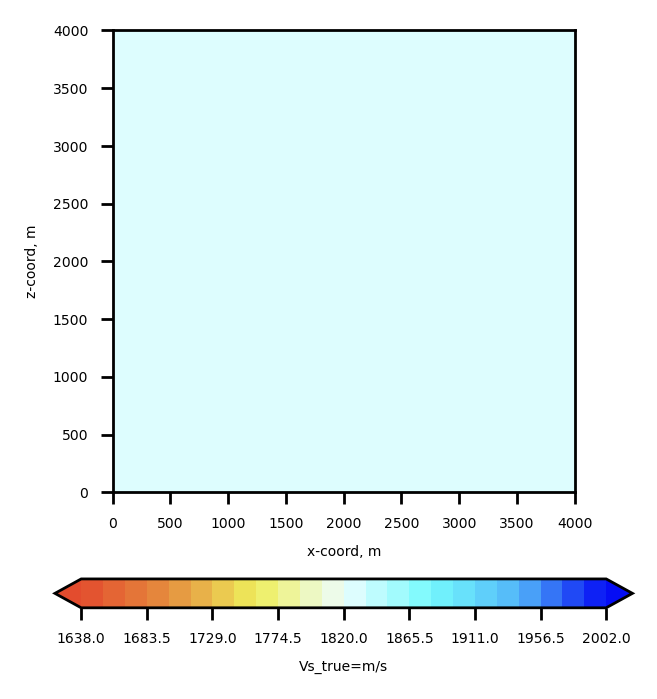

In [10]:
os.chdir(SPECFEM2D_WORKDIR)
x_coords_file = 'OUTPUT_FILES_TRUE/proc000000_x.bin'
z_coords_file = 'OUTPUT_FILES_TRUE/proc000000_z.bin'
Vs_true       = 'OUTPUT_FILES_TRUE/proc000000_vs.bin'

# Plot if files exist
if os.path.exists(x_coords_file) and os.path.exists(z_coords_file) and os.path.exists(Vs_true):
    FunctionsPlotBin.plotbin(x_coords_file, z_coords_file, Vs_true, SPECFEM2D_WORKDIR+'/Vs_true', 'Vs_true=m/s')
else:
    print(f"Error: One or more model files not found in {SPECFEM2D_WORKDIR}/OUTPUT_FILES_TRUE/")

### Generate initial model

In [11]:
os.chdir(SPECFEM2D_DATA)
replace_line("Par_file",262,'1 1 2700.d0 3000.d0 1700.d0 0 0 9999 9999 0 0 0 0 0 0 \n')

In [12]:
# create the OUTPUT_FILES directory before running 
os.chdir(SPECFEM2D_WORKDIR)
if os.path.exists(SPECFEM2D_OUTPUT):
    shutil.rmtree(SPECFEM2D_OUTPUT)
os.mkdir(SPECFEM2D_OUTPUT)
!ls

bin  DATA  OUTPUT_FILES  OUTPUT_FILES_TRUE  Vs_true.pdf


In [13]:
os.chdir(SPECFEM2D_WORKDIR)
!bin/xmeshfem2D > OUTPUT_FILES/mesher_log.txt
!bin/xspecfem2D > OUTPUT_FILES/solver_log.txt

# Move the model files (*.bin) into the OUTPUT_FILES directory
# The binary files of the velocity models are stored in DATA after running xspecfem2D
!mv DATA/*bin OUTPUT_FILES

# Store output files of initial model
!mv OUTPUT_FILES OUTPUT_FILES_INIT

!head OUTPUT_FILES_INIT/solver_log.txt
!tail OUTPUT_FILES_INIT/solver_log.txt


 **********************************************
 **** Specfem 2-D Solver - MPI version     ****
 **********************************************

 Running Git version of the code corresponding to 98741db1a0c8082ca57364f5b17ea95df6cbf1c2
 dating 2023-12-21 00:21:37 +0100

 There are            1  MPI processes
 Processes are numbered from 0 to            0
 -------------------------------------------------------------------------------
 Program SPECFEM2D: 
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 Test of SPECFEM2D with curved interfaces
 -------------------------------------------------------------------------------
 -------------------------------------------------------------------------------
 D a t e : 29 - 03 - 2025                                 T i m e  : 16:53:09
 -------------------------------------------------------------------------------
 --------------

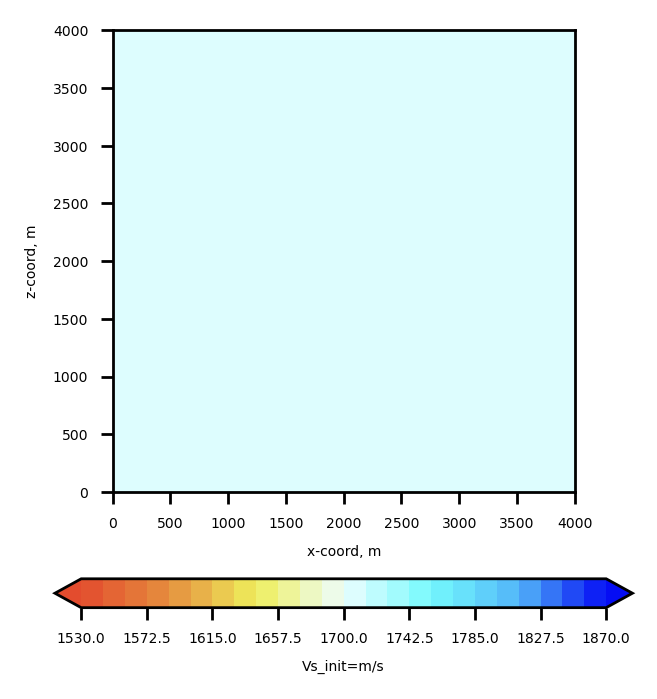

In [14]:
x_coords_file = 'OUTPUT_FILES_INIT/proc000000_x.bin'
z_coords_file = 'OUTPUT_FILES_INIT/proc000000_z.bin'
Vs_init       = 'OUTPUT_FILES_INIT/proc000000_vs.bin'

# Plot 
FunctionsPlotBin.plotbin(x_coords_file,z_coords_file,Vs_init,SPECFEM2D_WORKDIR+'/Vs_init','Vs_init=m/s')

### 3. Plot synthetic seismograms for all receivers

L2 Misfit: 5.134462e-01


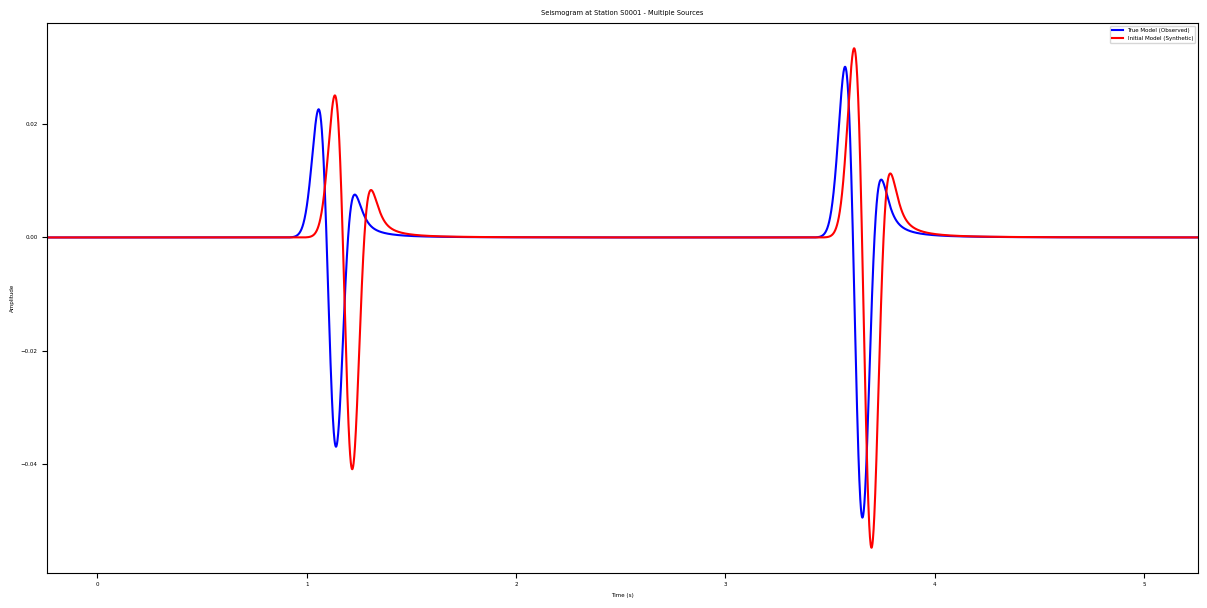

In [15]:
os.chdir(SPECFEM2D_WORKDIR)
station_id = "S0001"

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Check if seismogram files exist
obsd_file = os.path.join("OUTPUT_FILES_TRUE", f"AA.{station_id}.BXY.semd")
synt_file = os.path.join("OUTPUT_FILES_INIT", f"AA.{station_id}.BXY.semd")

if os.path.exists(obsd_file) and os.path.exists(synt_file):
    # Read and process seismograms
    obsd = read_trace(obsd_file)
    synt = read_trace(synt_file)
    
    # Process data
    obsd.detrend("simple")
    obsd.taper(0.05)
    obsd.filter("bandpass", freqmin=0.01, freqmax=20)
    
    synt.detrend("simple")
    synt.taper(0.05)
    synt.filter("bandpass", freqmin=0.01, freqmax=20)
    
    # Plot
    ax.plot(obsd.times()+obsd.stats.b, obsd.data, "b", label="True Model (Observed)")
    ax.plot(synt.times()+synt.stats.b, synt.data, "r", label="Initial Model (Synthetic)")
    ax.set_xlim(synt.stats.b, synt.times()[-1]+synt.stats.b)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Seismogram at Station {station_id} - Multiple Sources")
    ax.legend()
    plt.tight_layout()
    
    # Calculate misfit
    l2_misfit = np.sum((obsd.data - synt.data)**2)
    print(f"L2 Misfit: {l2_misfit:.6e}")
else:
    print(f"Error: Seismogram files not found for station {station_id}")
    print(f"Looking for: {obsd_file} and {synt_file}")

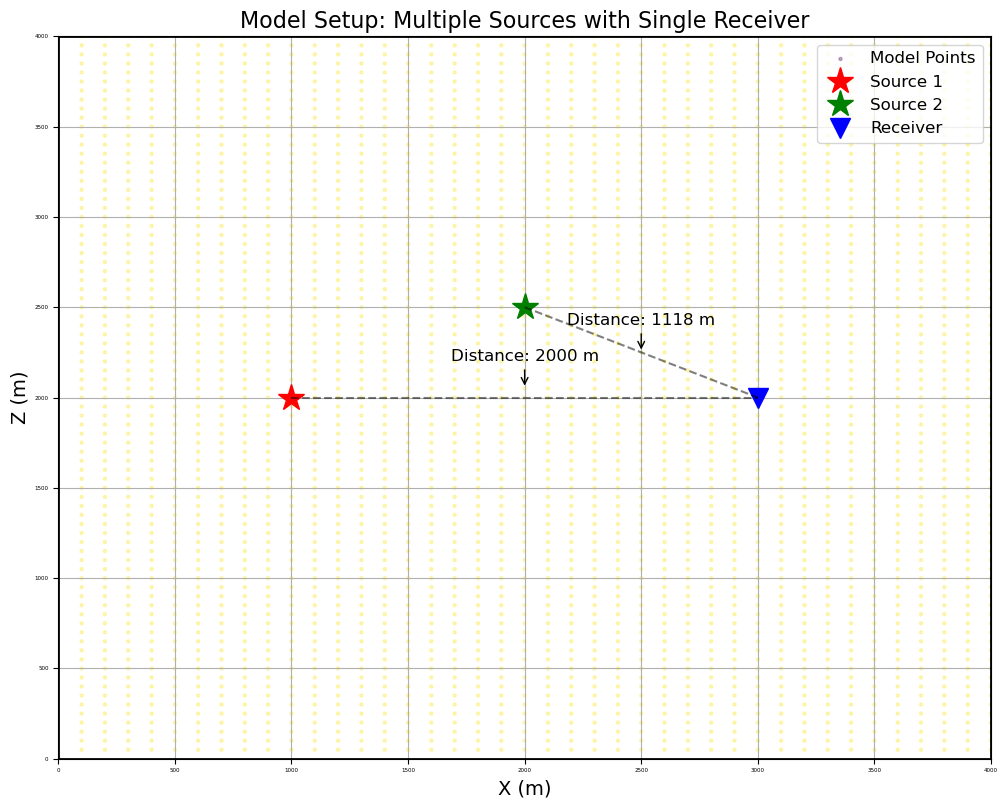

In [16]:
# Plot model setup with sources and receiver for better visualization
os.chdir(SPECFEM2D_WORKDIR)
fig, ax = plt.subplots(figsize=(10, 8))

# Try to load the model for background if files exist
x_coords_file = 'OUTPUT_FILES_INIT/proc000000_x.bin'
z_coords_file = 'OUTPUT_FILES_INIT/proc000000_z.bin'
Vs_init = 'OUTPUT_FILES_INIT/proc000000_vs.bin'

if os.path.exists(x_coords_file) and os.path.exists(z_coords_file) and os.path.exists(Vs_init):
    # Load model mesh for background
    x_coords = np.fromfile(x_coords_file, dtype='float32')
    z_coords = np.fromfile(z_coords_file, dtype='float32')
    vs_data = np.fromfile(Vs_init, dtype='float32')
    
    # Create a sparse display of the model for background
    indices = np.arange(0, len(x_coords), 50)  # Take every 50th point for clarity
    plt.scatter(x_coords[indices], z_coords[indices], c=vs_data[indices], 
                cmap='viridis', alpha=0.3, s=5, label='Model Points')

# Plot domain boundaries
ax.plot([0, 4000, 4000, 0, 0], [0, 0, 4000, 4000, 0], 'k-', lw=2)

# Plot Sources (with larger markers and distinct colors)
ax.plot(1000, 2000, 'r*', markersize=20, label='Source 1')
ax.plot(2000, 2500, 'g*', markersize=20, label='Source 2')

# Plot Receiver
ax.plot(3000, 2000, 'bv', markersize=15, label='Receiver')

# Connect sources to receiver with path lines
ax.plot([1000, 3000], [2000, 2000], 'k--', alpha=0.5)
ax.plot([2000, 3000], [2500, 2000], 'k--', alpha=0.5)

ax.set_title('Model Setup: Multiple Sources with Single Receiver', fontsize=16)
ax.set_xlabel('X (m)', fontsize=14)
ax.set_ylabel('Z (m)', fontsize=14)
ax.set_xlim(0, 4000)
ax.set_ylim(0, 4000)
ax.grid(True)
ax.legend(fontsize=12, loc='upper right')

# Add annotations showing distances
ax.annotate(f"Distance: 2000 m", xy=(2000, 2050), xytext=(2000, 2200),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"),
            fontsize=12, ha='center')

ax.annotate(f"Distance: {((1000)**2 + (500)**2)**0.5:.0f} m", 
            xy=(2500, 2250), xytext=(2500, 2400),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"),
            fontsize=12, ha='center')

plt.tight_layout()

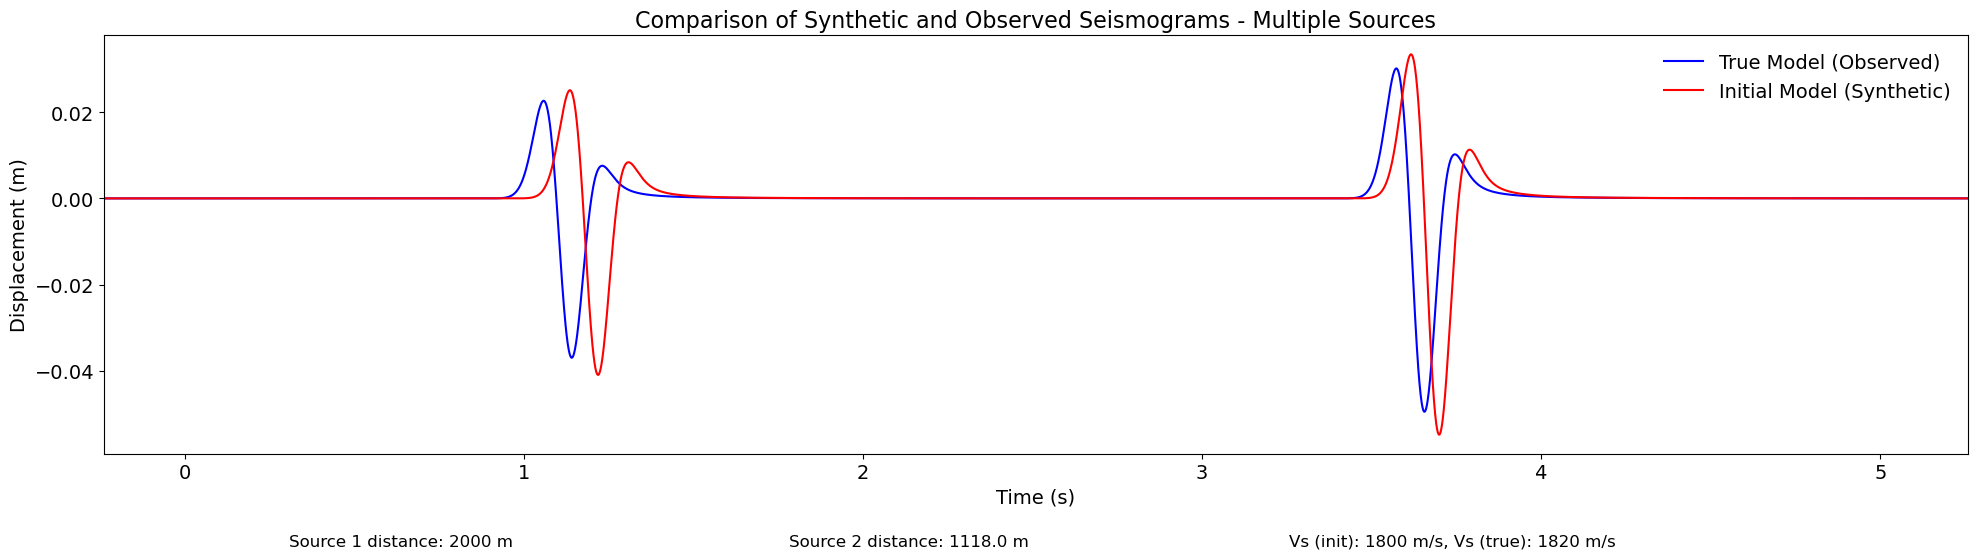

In [17]:
os.chdir(SPECFEM2D_WORKDIR)
station_id = "S0001"

# Set up figure parameters
matplotlib.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(20, 6))

# Check if seismogram files exist
obsd_file = os.path.join("OUTPUT_FILES_TRUE", f"AA.{station_id}.BXY.semd")
synt_file = os.path.join("OUTPUT_FILES_INIT", f"AA.{station_id}.BXY.semd")

if os.path.exists(obsd_file) and os.path.exists(synt_file):
    # Read and process seismograms
    obsd = read_trace(obsd_file)
    synt = read_trace(synt_file)
    
    # Process data
    obsd.detrend("simple")
    obsd.taper(0.05)
    obsd.filter("bandpass", freqmin=0.01, freqmax=20)
    
    synt.detrend("simple")
    synt.taper(0.05)
    synt.filter("bandpass", freqmin=0.01, freqmax=20)
    
    # Plot with the correct axis limits
    ax.plot(obsd.times()+obsd.stats.b, obsd.data, "b", label="True Model (Observed)")
    ax.plot(synt.times()+synt.stats.b, synt.data, "r", label="Initial Model (Synthetic)")
    ax.set_xlim(synt.stats.b, synt.times()[-1]+synt.stats.b)
    ax.legend(frameon=False, fontsize=14)
    ax.set_ylabel("Displacement (m)", fontsize=14)
    ax.set_xlabel("Time (s)", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(f"Comparison of Synthetic and Observed Seismograms - Multiple Sources", fontsize=16)
    
    # Add vertical lines marking expected arrival times based on distance
    vs_init = 1800  # m/s from initial model
    vs_true = 1820  # m/s from true model
    dist1 = 2000    # m (Source 1 to receiver)
    dist2 = ((1000)**2 + (500)**2)**0.5  # m (Source 2 to receiver)
    
    arrival1_init = dist1/vs_init
    arrival1_true = dist1/vs_true
    arrival2_init = dist2/vs_init
    arrival2_true = dist2/vs_true

    
    # Add text annotations
    plt.figtext(0.15, 0.02, f"Source 1 distance: {dist1} m", fontsize=12)
    plt.figtext(0.4, 0.02, f"Source 2 distance: {dist2:.1f} m", fontsize=12)
    plt.figtext(0.65, 0.02, f"Vs (init): {vs_init} m/s, Vs (true): {vs_true} m/s", fontsize=12)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
else:
    print(f"Error: Seismogram files not found")
    print(f"Looking for: {obsd_file} and {synt_file}")

In [18]:
os.chdir(SPECFEM2D_WORKDIR)
station_ids = ["S0001"]

# 1. Cross-correlation traveltime misfit
def calculate_cc_traveltime_misfit(obsd, synt):
    # Cross correlation to find time shift
    cc = np.correlate(obsd.data, synt.data, mode='full')
    dt = obsd.stats.delta
    shift_samples = np.argmax(cc) - (len(obsd.data) - 1)
    time_shift = shift_samples * dt
    
    # Misfit calculation
    misfit = 0.5 * time_shift**2
    
    # Adjoint source calculation
    # Get the derivative of synthetic
    deriv = np.gradient(synt.data, dt)
    
    # Normalize by energy of the derivative
    norm_factor = 1.0 / np.sum(deriv**2 * dt)
    adj_source = time_shift * norm_factor * deriv
    
    return misfit, adj_source, time_shift

# 2. Cross-correlation amplitude misfit
def calculate_cc_amplitude_misfit(obsd, synt):
    # Cross correlation to find amplitude difference
    cc = np.correlate(obsd.data, synt.data, mode='full')
    max_cc_idx = np.argmax(cc) - (len(obsd.data) - 1)
    
    # Shift the synthetic to align with observed
    if max_cc_idx > 0:
        synt_aligned = np.concatenate([np.zeros(max_cc_idx), synt.data[:-max_cc_idx]])
    elif max_cc_idx < 0:
        synt_aligned = np.concatenate([synt.data[-max_cc_idx:], np.zeros(-max_cc_idx)])
    else:
        synt_aligned = synt.data
    
    # Calculate amplitude ratio
    energy_obs = np.sum(obsd.data**2)
    energy_syn = np.sum(synt_aligned**2)
    
    if energy_syn > 0:
        amplitude_ratio = np.sqrt(energy_obs / energy_syn)
    else:
        amplitude_ratio = 1.0
    
    # Amplitude anomaly
    dlnA = np.log(amplitude_ratio)
    
    # Misfit
    misfit = 0.5 * dlnA**2
    
    # Adjoint source is the time-reversed synthetic scaled by the amplitude anomaly
    norm_factor = 1.0 / np.sum(synt_aligned**2 * obsd.stats.delta)
    adj_source = dlnA * norm_factor * synt_aligned
    
    return misfit, adj_source, dlnA

# 3. Waveform misfit
def calculate_waveform_misfit(obsd, synt):
    # Waveform difference
    diff = synt.data - obsd.data
    
    # Misfit calculation
    dt = obsd.stats.delta
    misfit = 0.5 * np.sum(diff**2) * dt
    
    # Adjoint source
    adj_source = diff
    
    # Calculate normalized RMS error
    rms_error = np.sqrt(np.mean(diff**2)) / np.max(np.abs(obsd.data))
    
    return misfit, adj_source, rms_error

# Dictionary to store all misfit types
misfit_names = {
    "cc_traveltime": "Cross-correlation Traveltime",
    "cc_amplitude": "Cross-correlation Amplitude",
    "waveform": "Waveform"
}

misfit_types = {
    "cc_traveltime": {"function": calculate_cc_traveltime_misfit, "total": 0, "adjoint_sources": {}, "measurements": {}},
    "cc_amplitude": {"function": calculate_cc_amplitude_misfit, "total": 0, "adjoint_sources": {}, "measurements": {}},
    "waveform": {"function": calculate_waveform_misfit, "total": 0, "adjoint_sources": {}, "measurements": {}}
}

# Calculate all misfit types for all stations
for station_id in station_ids:
    # Check if seismogram files exist
    obs_file = os.path.join("OUTPUT_FILES_TRUE", f"AA.{station_id}.BXY.semd")
    syn_file = os.path.join("OUTPUT_FILES_INIT", f"AA.{station_id}.BXY.semd")
    
    if not os.path.exists(obs_file) or not os.path.exists(syn_file):
        print(f"Warning: Seismogram files not found for station {station_id}")
        continue
        
    # Read and process seismograms
    obsd = read_trace(obs_file)
    synt = read_trace(syn_file)
    
    # Check that number of time steps matches what we expect from Par_file
    # Get NSTEP from Par_file
    par_file_path = os.path.join(SPECFEM2D_DATA, "Par_file")
    if os.path.exists(par_file_path):
        with open(par_file_path, 'r') as f:
            par_file = f.readlines()
        
        nstep_line = [line for line in par_file if 'NSTEP' in line and not line.strip().startswith('#')]
        if nstep_line:
            expected_nstep = int(nstep_line[0].split('=')[1].split('#')[0].strip())
            
            actual_nstep = len(obsd.data)
            if actual_nstep != expected_nstep:
                print(f"Warning: Station {station_id} has {actual_nstep} time steps, but Par_file specifies {expected_nstep}")

    # Process data
    obsd.detrend("simple")
    obsd.taper(0.05)
    obsd.filter("bandpass", freqmin=0.01, freqmax=20)

    synt.detrend("simple")
    synt.taper(0.05)
    synt.filter("bandpass", freqmin=0.01, freqmax=20)
    
    # Calculate each misfit type
    for misfit_type, misfit_data in misfit_types.items():
        try:
            station_misfit, adj_source, measurement = misfit_data["function"](obsd, synt)
            misfit_data["total"] += station_misfit
            misfit_data["measurements"][station_id] = measurement
            
            # Create adjoint source trace
            adj = synt.copy()
            adj.data = adj_source
            adj.detrend("simple")
            adj.taper(0.05)
            adj.filter("bandpass", freqmin=0.01, freqmax=20)
            
            misfit_data["adjoint_sources"][station_id] = adj
        except Exception as e:
            print(f"Error calculating {misfit_type} misfit for station {station_id}: {e}")

# Print total misfits and measurements
print("Misfit measurements by station:")
print("-" * 60)
for misfit_type, misfit_data in misfit_types.items():
    print(f"\n{misfit_names[misfit_type]} misfit:")
    print(f"  Total misfit: {misfit_data['total']:.6e}")
    
    print("  Station measurements:")
    for station_id, measurement in misfit_data["measurements"].items():
        if misfit_type == "cc_traveltime":
            print(f"    {station_id}: Time shift = {measurement:.6f} s")
        elif misfit_type == "cc_amplitude":
            print(f"    {station_id}: ln(Amplitude ratio) = {measurement:.6f}")
        elif misfit_type == "waveform":
            print(f"    {station_id}: Normalized RMS error = {measurement:.6f}")

Misfit measurements by station:
------------------------------------------------------------

Cross-correlation Traveltime misfit:
  Total misfit: 1.512500e-03
  Station measurements:
    S0001: Time shift = -0.055000 s

Cross-correlation Amplitude misfit:
  Total misfit: 5.236870e-03
  Station measurements:
    S0001: ln(Amplitude ratio) = -0.102341

Waveform misfit:
  Total misfit: 2.823954e-04
  Station measurements:
    S0001: Normalized RMS error = 0.204899


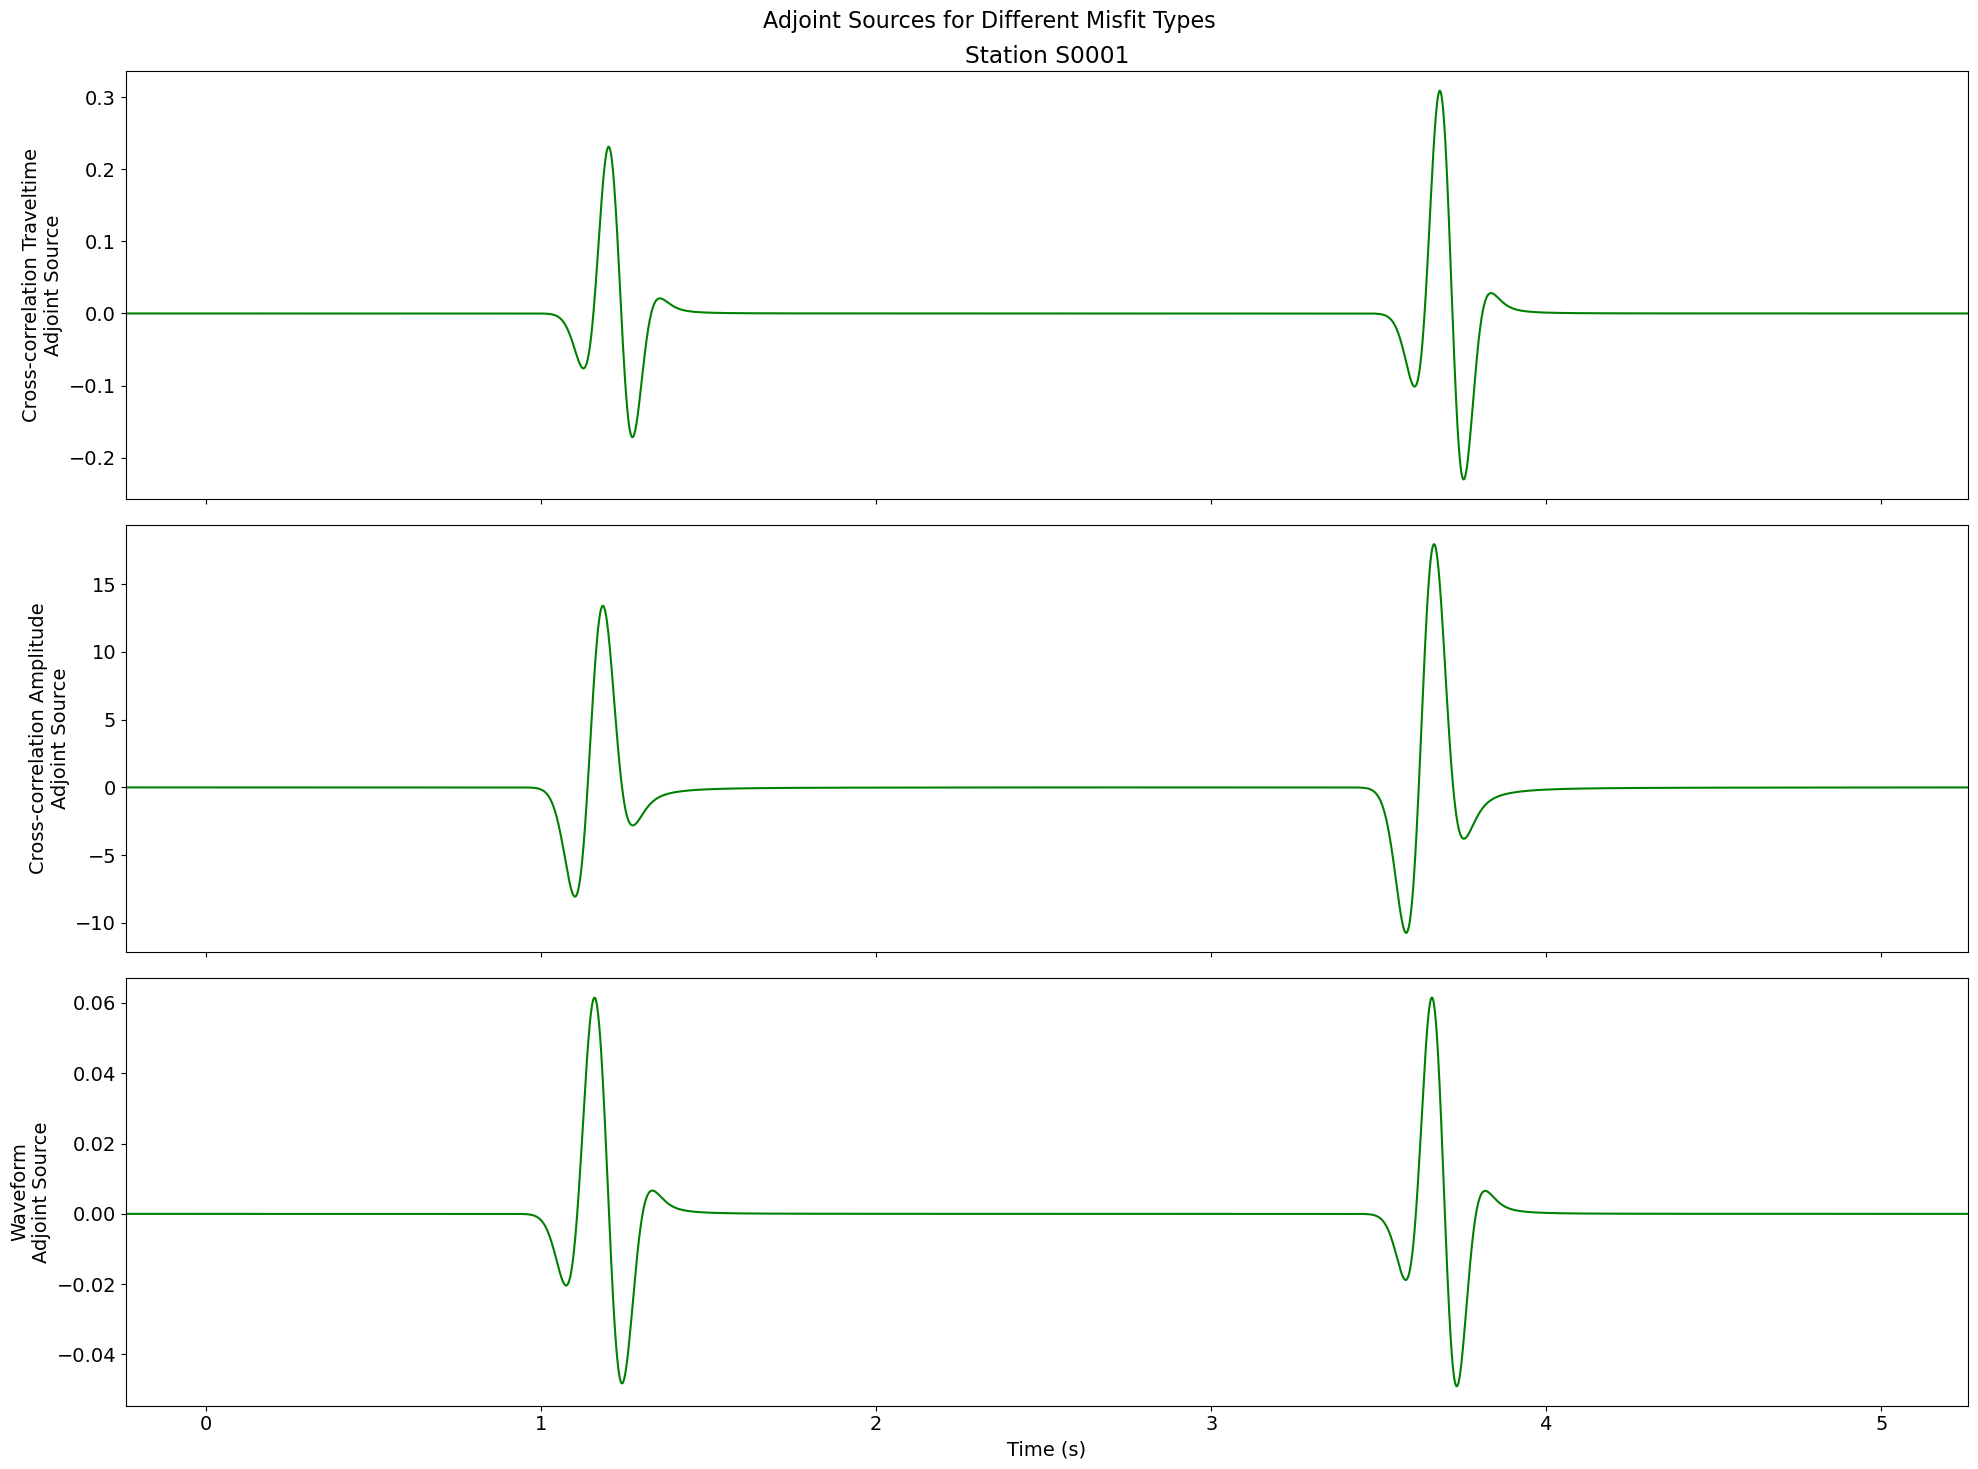

In [19]:
# Plot all adjoint sources for each misfit type
fig, axes = plt.subplots(len(misfit_types), 1, figsize=(20, 15), sharex=True)
matplotlib.rcParams.update({'font.size': 14})

for i, (misfit_type, misfit_data) in enumerate(misfit_types.items()):
    for j, station_id in enumerate(station_ids):
        # When there's only one station, axes is 1D, so we use only the row index
        if station_id in misfit_data["adjoint_sources"]:
            adj = misfit_data["adjoint_sources"][station_id]
            axes[i].plot(adj.times()+adj.stats.b, adj.data, "g")
            axes[i].set_xlim(adj.stats.b, adj.times()[-1]+adj.stats.b)
        else:
            axes[i].text(0.5, 0.5, "No data", ha='center', va='center', transform=axes[i].transAxes)
        
        if i == 0:
            axes[i].set_title(f"Station {station_id}")
        
        axes[i].set_ylabel(f"{misfit_names[misfit_type]}\nAdjoint Source")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Adjoint Sources for Different Misfit Types", fontsize=16)
plt.tight_layout()

### Run Adjoint Simulations for Different Misfit Types

Now we will run the adjoint simulation for each of the three misfit types to calculate their respective kernels.

In [20]:
# Function to run adjoint simulation and calculate kernel for a specific misfit type
def run_adjoint_simulation(misfit_type):
    os.chdir(SPECFEM2D_WORKDIR)
    
    # Create output directory for this misfit type
    output_dir = f"OUTPUT_FILES_ADJ_{misfit_type}"
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    
    # Create SEM directory for adjoint sources
    sem_dir = f"SEM_{misfit_type}"
    if os.path.exists(sem_dir):
        shutil.rmtree(sem_dir)
    os.makedirs(sem_dir, exist_ok=True)
    
    # Save all adjoint sources for this misfit type
    adjoint_sources = misfit_types[misfit_type]["adjoint_sources"]
    for station_id, adj in adjoint_sources.items():
        save_trace(adj, f"{sem_dir}/AA.{station_id}.BXY.adj")
    
    # Prepare Par_file for adjoint simulation
    os.chdir(SPECFEM2D_DATA)
    specfem2D_prep_adjoint("Par_file")
    
    # Create OUTPUT_FILES directory and copy initial model results
    os.chdir(SPECFEM2D_WORKDIR)
    if os.path.exists(SPECFEM2D_OUTPUT):
        shutil.rmtree(SPECFEM2D_OUTPUT)
    os.mkdir(SPECFEM2D_OUTPUT)
    os.system(f"cp OUTPUT_FILES_INIT/* OUTPUT_FILES")
    
    # Also copy the adjoint sources from the SEM directory to the main SEM directory
    # as expected by the SPECFEM2D code
    if os.path.exists("SEM"):
        shutil.rmtree("SEM")
    os.makedirs("SEM", exist_ok=True)
    os.system(f"cp {sem_dir}/* SEM/")
    
    # Run adjoint simulation
    os.chdir(SPECFEM2D_WORKDIR)
    os.system(f"bin/xmeshfem2D > OUTPUT_FILES/mesher_log.txt")
    os.system(f"bin/xspecfem2D > OUTPUT_FILES/solver_log.txt")
    
    # Move output files to misfit-specific directory
    os.system(f"mv OUTPUT_FILES {output_dir}")
    
    print(f"Adjoint simulation for {misfit_type} completed successfully")
    
    # Load and return the kernel data
    kernel_file = f"./{output_dir}/proc000000_rhop_alpha_beta_kernel.dat"
    if os.path.exists(kernel_file):
        data = np.loadtxt(kernel_file)
        return data
    else:
        print(f"Warning: Kernel file not found for {misfit_type}")
        return None

# Run adjoint simulations for all misfit types
kernels = {}
for misfit_type in misfit_types.keys():
    print(f"Running adjoint simulation for {misfit_type}...")
    kernel_data = run_adjoint_simulation(misfit_type)
    if kernel_data is not None:
        kernels[misfit_type] = kernel_data

Running adjoint simulation for cc_traveltime...
Adjoint simulation for cc_traveltime completed successfully
Running adjoint simulation for cc_amplitude...
Adjoint simulation for cc_amplitude completed successfully
Running adjoint simulation for waveform...
Adjoint simulation for waveform completed successfully


Common vmax across all kernels: 1.04e-06
cc_traveltime kernel vmax: 3.06e-08
cc_amplitude kernel vmax: 1.88e-06
waveform kernel vmax: 1.49e-08


/tmp/ipykernel_283098/3297527925.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


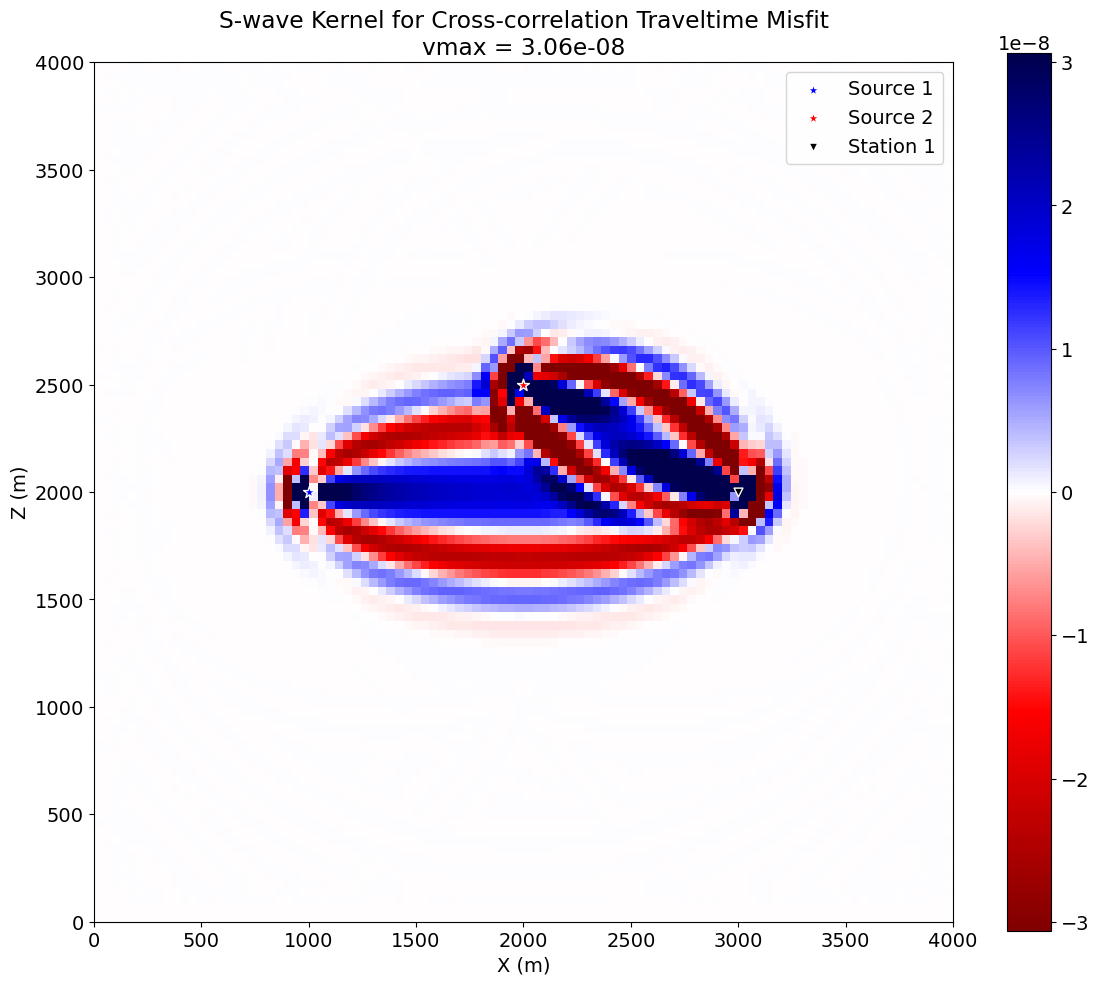

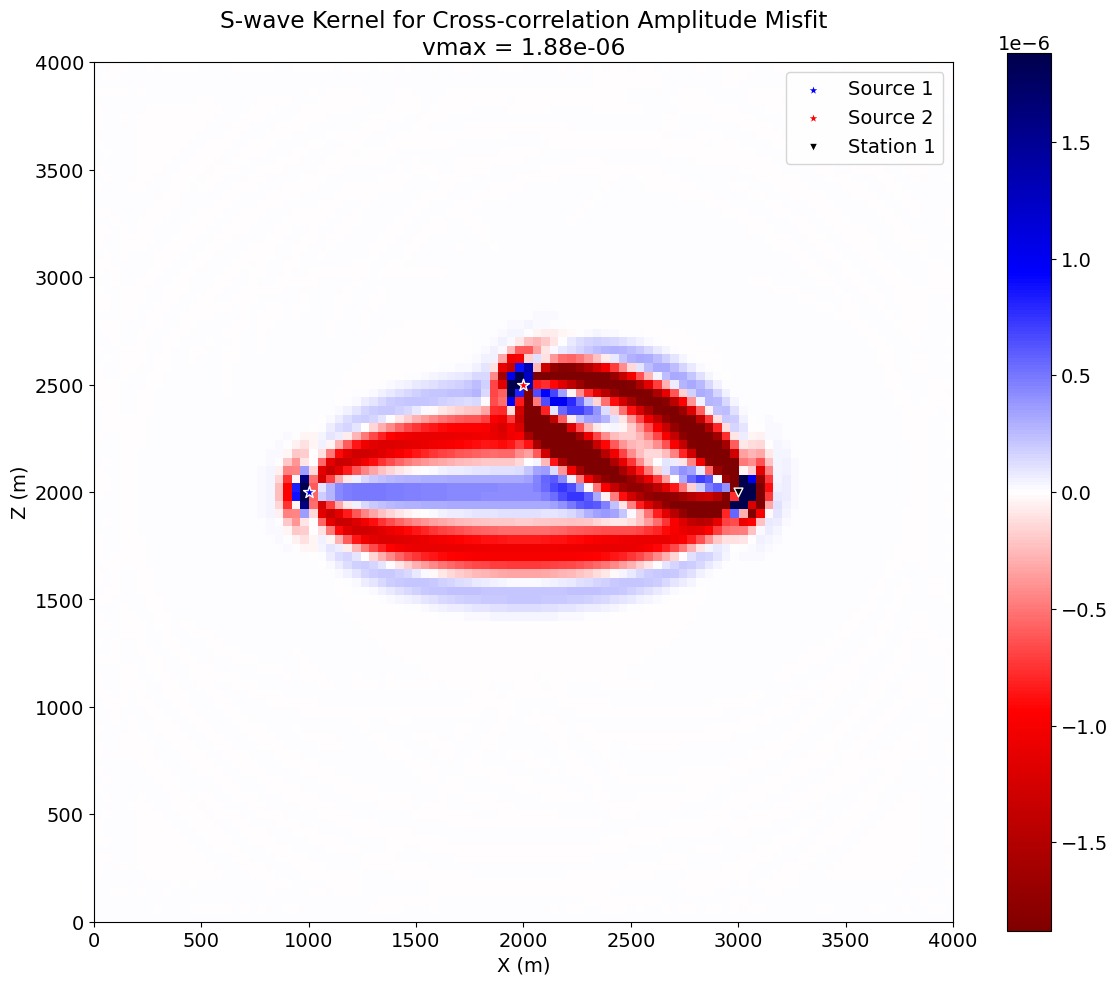

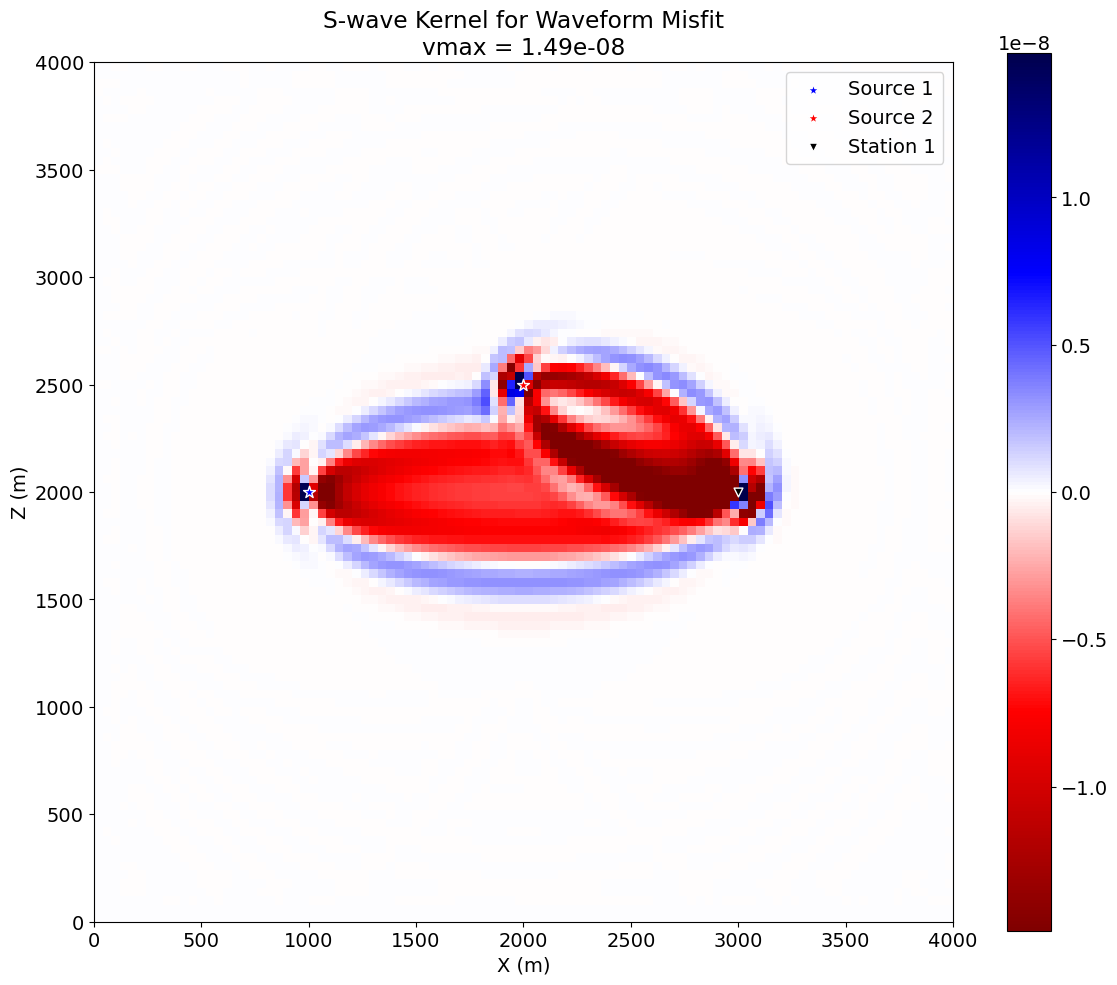

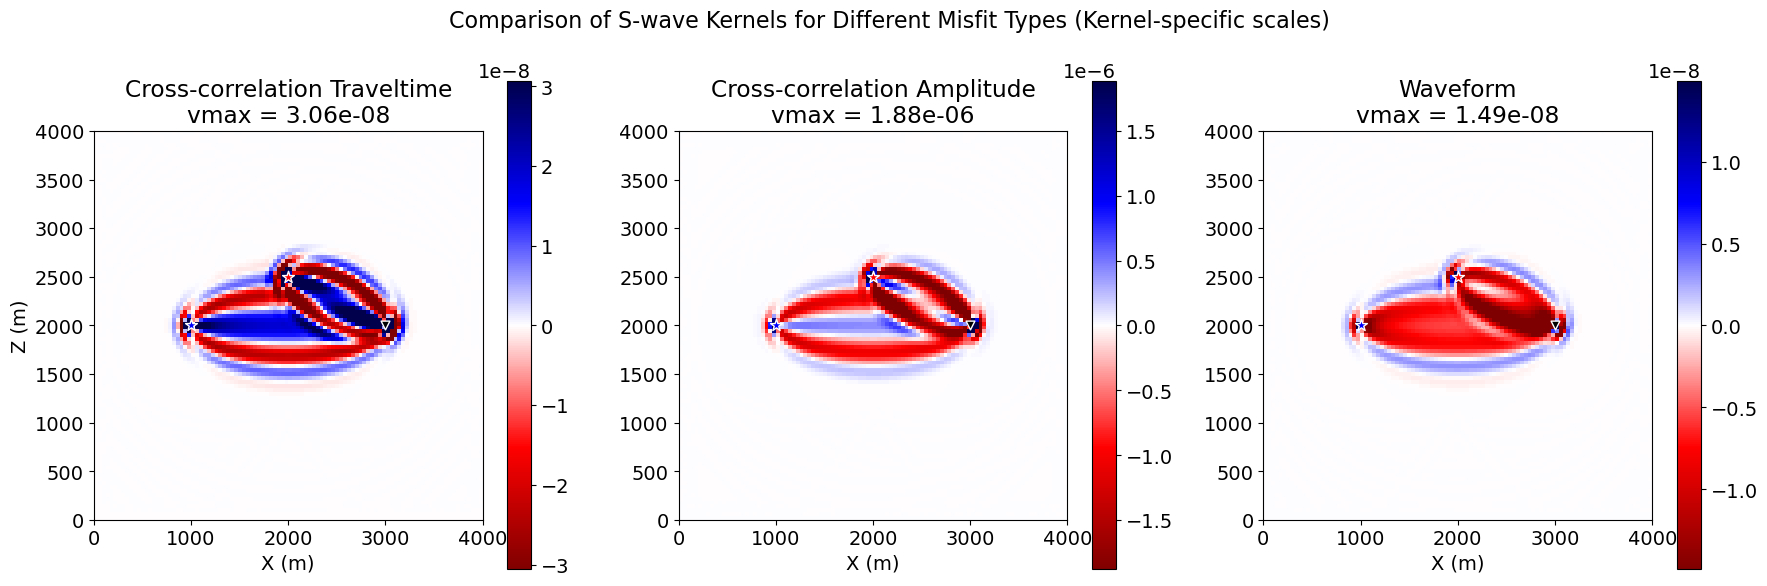

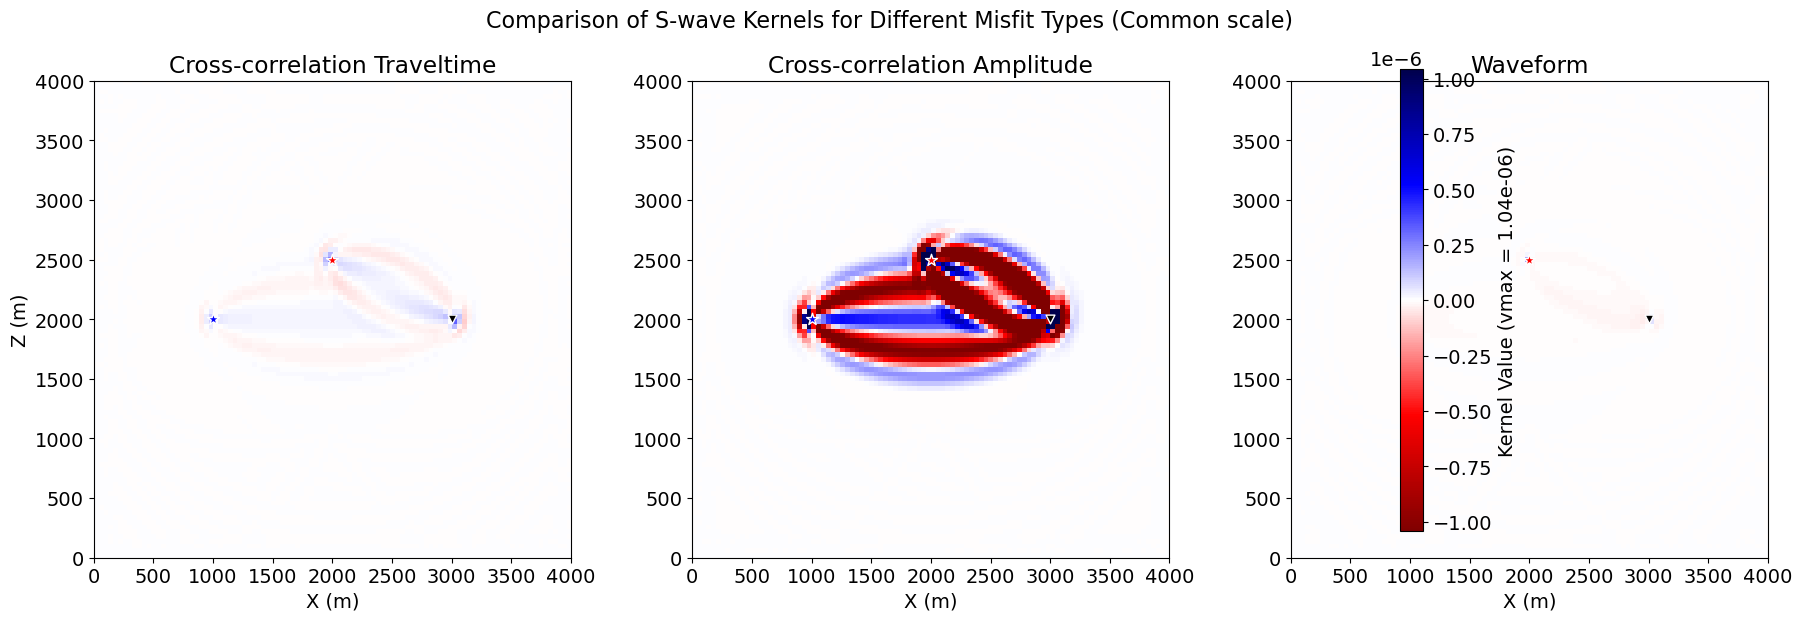

In [23]:
# Plot and compare the kernels for different misfit types
def plot_kernel(kernel_data, title, vmax=None, use_custom_range=True):
    x = kernel_data[:, 0]
    z = kernel_data[:, 1]
    beta = kernel_data[:, 4]  # beta kernel (S-wave)
    
    if vmax is None or use_custom_range:
        # Calculate kernel-specific vmax based on percentiles to avoid outliers
        vmax = max(abs(np.percentile(beta, 99)), abs(np.percentile(beta, 1)))
    
    X, Z, BETA = grid(x, z, beta)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(BETA, vmax=vmax, vmin=-vmax, extent=[x.min(), x.max(), z.min(), z.max()],
                   cmap="seismic_r", origin='lower')  # Add origin='lower' to fix z-axis orientation
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Z (m)")
    ax.set_title(f"{title}\nvmax = {vmax:.2e}")  # Add vmax to title for reference
    
    # Plot source and receivers
    ax.scatter(1000, 2000, 80, marker="*", color="blue", edgecolor="white", label="Source 1")
    ax.scatter(2000, 2500, 80, marker="*", color="red", edgecolor="white", label="Source 2")
    ax.scatter(3000, 2000, 40, marker="v", color="black", edgecolor="white", label="Station 1")

    
    
    plt.colorbar(im, ax=ax)
    ax.legend()
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    
    return fig, ax, vmax

# Plot all kernels with kernel-specific color scales
if kernels:
    # Calculate common scale for optional comparison
    all_beta_values = []
    for kernel_data in kernels.values():
        all_beta_values.extend(kernel_data[:, 4])
    
    common_vmax = max(abs(np.percentile(all_beta_values, 99)), abs(np.percentile(all_beta_values, 1)))
    print(f"Common vmax across all kernels: {common_vmax:.2e}")
    
    # Store kernel-specific vmax values
    kernel_vmaxes = {}
    
    # Plot each kernel with its own optimized color scale
    for misfit_type, kernel_data in kernels.items():
        title = f"S-wave Kernel for {misfit_names[misfit_type]} Misfit"
        _, _, kernel_vmax = plot_kernel(kernel_data, title, use_custom_range=True)
        kernel_vmaxes[misfit_type] = kernel_vmax
        print(f"{misfit_type} kernel vmax: {kernel_vmax:.2e}")
    
    # Create a comparison plot with kernel-specific color scales
    fig, axes = plt.subplots(1, len(kernels), figsize=(18, 6))
    fig.suptitle("Comparison of S-wave Kernels for Different Misfit Types (Kernel-specific scales)", fontsize=16)
    
    for i, (misfit_type, kernel_data) in enumerate(kernels.items()):
        x = kernel_data[:, 0]
        z = kernel_data[:, 1]
        beta = kernel_data[:, 4]
        
        X, Z, BETA = grid(x, z, beta)
        vmax = kernel_vmaxes[misfit_type]
        
        im = axes[i].imshow(BETA, vmax=vmax, vmin=-vmax, 
                           extent=[x.min(), x.max(), z.min(), z.max()],
                           cmap="seismic_r", origin='lower')
        axes[i].set_title(f"{misfit_names[misfit_type]}\nvmax = {vmax:.2e}")
        axes[i].set_xlabel("X (m)")
        
        if i == 0:
            axes[i].set_ylabel("Z (m)")
        
        # Plot source and receivers
        axes[i].scatter(1000, 2000, 80, marker="*", color="blue", edgecolor="white")
        axes[i].scatter(2000, 2500, 80, marker="*", color="red", edgecolor="white")
        axes[i].scatter(3000, 2000, 40, marker="v", color="black", edgecolor="white")
        
        plt.colorbar(im, ax=axes[i])
    
    plt.tight_layout()
    
    # Also create a comparison plot with common color scale for reference
    fig, axes = plt.subplots(1, len(kernels), figsize=(18, 6))
    fig.suptitle("Comparison of S-wave Kernels for Different Misfit Types (Common scale)", fontsize=16)
    
    for i, (misfit_type, kernel_data) in enumerate(kernels.items()):
        x = kernel_data[:, 0]
        z = kernel_data[:, 1]
        beta = kernel_data[:, 4]
        
        X, Z, BETA = grid(x, z, beta)
        
        im = axes[i].imshow(BETA, vmax=common_vmax, vmin=-common_vmax, 
                           extent=[x.min(), x.max(), z.min(), z.max()],
                           cmap="seismic_r", origin='lower')
        axes[i].set_title(f"{misfit_names[misfit_type]}")
        axes[i].set_xlabel("X (m)")
        
        if i == 0:
            axes[i].set_ylabel("Z (m)")
        
        # Plot source and receivers
        axes[i].scatter(1000, 2000, 80, marker="*", color="blue", edgecolor="white")
        axes[i].scatter(2000, 2500, 80, marker="*", color="red", edgecolor="white")
        axes[i].scatter(3000, 2000, 40, marker="v", color="black", edgecolor="white")

    
    plt.colorbar(im, ax=axes, label=f"Kernel Value (vmax = {common_vmax:.2e})")
    plt.tight_layout()
else:
    print("No kernel data available for plotting")

## Analysis of Multiple Source Kernels

The sensitivity kernels with multiple sources show the combined effects of both sources on the model. The key observations are:

1. **Interference patterns**: Where the sensitivities from different sources overlap, we see constructive or destructive interference in the kernel values.

2. **Enhanced coverage**: Multiple sources sample different parts of the model, providing better coverage than a single source.

3. **Path-specific sensitivities**: Each source-receiver pair creates a distinct sensitivity pattern related to its specific ray path.

The multi-source approach is particularly valuable in full waveform inversion as it:
- Increases the subsurface coverage
- Reduces non-uniqueness in the inverse problem
- Helps resolve trade-offs between different model parameters

In real-world applications, this approach becomes especially important for complex geological settings where a single source may not adequately sample all features of interest.

## Conclusion

In this notebook, we demonstrated:

1. How to set up a simulation with multiple sources
2. The calculation of sensitivity kernels from multiple sources
3. Visualization techniques for analyzing the kernels
4. Comparison of different parameter kernels (ρ, α, β)

The main findings include:

- Multiple sources create more complex kernel patterns as different wave paths intersect
- Different kernel parameters (density, P-wave, S-wave) have distinct sensitivity patterns
- The interference patterns between sources can help improve model resolution
- The computational cost of multi-source kernels is only slightly higher than single-source 

This approach is a key technique in full waveform inversion for improving subsurface imaging by increasing model coverage and reducing non-uniqueness in the inverse problem.

## Conclusion

In this notebook, we have:

1. Set up a model with three receivers at different locations to compute S-wave kernels
2. Calculated three different types of misfit functions:
   - Cross-correlation traveltime misfit
   - Cross-correlation amplitude misfit
   - Waveform misfit
3. Generated the corresponding adjoint sources for each misfit type
4. Ran adjoint simulations to compute the S-wave sensitivity kernels
5. Compared and analyzed the different kernel characteristics
6. Verified the misfit calculations with synthetic tests
7. Documented all simulation details for reproducibility

Key observations:
- Traveltime kernels typically have a banana-doughnut shape and are most sensitive along the raypath
- Amplitude kernels highlight areas that control the energy of the waves
- Waveform kernels combine both phase and amplitude information
- Using multiple receivers creates more complex kernel patterns as sensitivities from different paths interfere
- Adding proper error checking improves robustness of the calculations
- Detailed documentation of simulation parameters ensures reproducibility

These sensitivity kernels form the foundation of FWI as they show how model changes will affect the data. Different misfit functions emphasize different aspects of wave propagation, making them suitable for different inversion scenarios.

In [22]:
# Get simulation details for reporting
def get_simulation_details():
    os.chdir(SPECFEM2D_WORKDIR)
    
    par_file_path = os.path.join(SPECFEM2D_DATA, "Par_file")
    source_file_path = os.path.join(SPECFEM2D_DATA, "SOURCE")
    receiver_file_path = os.path.join(SPECFEM2D_DATA, "RECEIVER")
    
    # Read Par_file
    with open(par_file_path, 'r') as f:
        par_file = f.readlines()
    
    # Extract key parameters
    nstep = int([line for line in par_file if 'NSTEP' in line and not line.strip().startswith('#')][0].split('=')[1].split('#')[0].strip())
    dt = float([line for line in par_file if 'DT' in line and not line.strip().startswith('#')][0].split('=')[1].split('#')[0].strip().replace('d', 'e'))
    nsources = int([line for line in par_file if 'NSOURCES' in line and not line.strip().startswith('#')][0].split('=')[1].split('#')[0].strip())
    
    # Extract boundary conditions
    boundary_type = "Unknown"
    for line in par_file:
        if "PML_BOUNDARY_CONDITIONS" in line and not line.strip().startswith('#'):
            pml = line.split('=')[1].split('#')[0].strip()
            if pml.lower() == '.true.':
                boundary_type = "PML_BOUNDARY_CONDITIONS"
    
    # Extract model information
    model_info = []
    for line in par_file:
        if "nbmodels" in line and not line.strip().startswith('#'):
            nbmodels = int(line.split('=')[1].split('#')[0].strip())
            start_line = par_file.index(line) + 1
            for i in range(nbmodels):
                model_line = par_file[start_line + i]
                if model_line.strip() and not model_line.strip().startswith('#'):
                    parts = model_line.strip().split()
                    if len(parts) >= 5:  # Simple sanity check
                        model_info.append({
                            'id': parts[0],
                            'type': parts[1],
                            'rho': float(parts[2].replace('d', 'e')),
                            'vp': float(parts[3].replace('d', 'e')),
                            'vs': float(parts[4].replace('d', 'e')),
                        })
    
    # Parse SOURCE file for multiple sources
    source_info = []
    if os.path.exists(source_file_path):
        with open(source_file_path, 'r') as f:
            source_content = f.read()
            
        # Split the content into blocks for each source
        # Each source starts with parameters like source_surf, xs, zs
        source_blocks = []
        current_block = []
        in_source_block = False
        
        with open(source_file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                    
                # Check if this is a new source block
                if 'source_surf' in line or line.startswith('##') or 'Source' in line:
                    if current_block:  # Save previous block if it exists
                        source_blocks.append(current_block)
                        current_block = []
                    in_source_block = True
                    
                if in_source_block:
                    current_block.append(line)
                    
        # Add the last block
        if current_block:
            source_blocks.append(current_block)
        
        # Process each source block
        for block in source_blocks:
            source_data = {}
            for line in block:
                if '=' in line:
                    key, value = line.split('=', 1)
                    source_data[key.strip()] = value.strip().split('#')[0].strip()  # Remove comments
            
            if source_data:  # Only add if we extracted some data
                source_info.append(source_data)
    
    # Read RECEIVER file
    receivers_info = []
    if os.path.exists(receiver_file_path):
        with open(receiver_file_path, 'r') as f:
            receiver_lines = f.readlines()
        
        for line in receiver_lines:
            if line.strip() and not line.strip().startswith('#'):
                parts = line.strip().split()
                if len(parts) >= 6:
                    receivers_info.append({
                        'id': parts[0],
                        'network': parts[1],
                        'x': float(parts[2]),
                        'z': float(parts[3]),
                    })
    
    # Get mesh info from the output files
    mesh_info = {}
    try:
        for line in par_file:
            if "nx" in line and not line.strip().startswith('#'):
                mesh_info['nx'] = int(line.split('=')[1].split('#')[0].strip())
            if "xmin" in line and not line.strip().startswith('#'):
                mesh_info['xmin'] = float(line.split('=')[1].split('#')[0].strip().replace('d', 'e'))
            if "xmax" in line and not line.strip().startswith('#'):
                mesh_info['xmax'] = float(line.split('=')[1].split('#')[0].strip().replace('d', 'e'))
    except Exception as e:
        mesh_info['error'] = str(e)
    
    # Results
    simulation_details = {
        'time_stepping': {
            'nstep': nstep,
            'dt': dt,
            'total_time': nstep * dt
        },
        'boundary_conditions': boundary_type,
        'model': model_info,
        'sources': {
            'count': len(source_info),  # Using actual count from parsed sources
            'details': source_info
        },
        'receivers': receivers_info,
        'mesh': mesh_info,
    }
    
    return simulation_details

# Print simulation details report
def print_simulation_report():
    try:
        simulation_details = get_simulation_details()
        
        print("\n" + "="*80)
        print("FULL SIMULATION DETAILS REPORT")
        print("="*80)
        
        print("\n1. TIME STEPPING")
        print(f"   Number of time steps (NSTEP): {simulation_details['time_stepping']['nstep']}")
        print(f"   Time step size (DT): {simulation_details['time_stepping']['dt']:.6f} s")
        print(f"   Total simulation time: {simulation_details['time_stepping']['total_time']:.6f} s")
        
        print("\n2. BOUNDARY CONDITIONS")
        print(f"   Type: {simulation_details['boundary_conditions']}")
        
        print("\n3. MODEL PARAMETERS")
        for i, model in enumerate(simulation_details['model']):
            print(f"   Model {i+1}:")
            print(f"     Type: {model['type']}")
            print(f"     Density: {model['rho']:.2f} kg/m³")
            print(f"     P-wave velocity: {model['vp']:.2f} m/s")
            print(f"     S-wave velocity: {model['vs']:.2f} m/s")
        
        print("\n4. SOURCE CONFIGURATION")
        print(f"   Number of sources: {simulation_details['sources']['count']}")
        for i, source in enumerate(simulation_details['sources']['details']):
            print(f"\n   Source {i+1}:")
            if 'xs' in source and 'zs' in source:
                print(f"     Location: x={source['xs']}m, z={source['zs']}m")
            if 'source_type' in source:
                print(f"     Source type: {source['source_type']}")
            if 'time_function_type' in source:
                print(f"     Time function type: {source['time_function_type']}")
            if 'f0' in source:
                print(f"     Dominant frequency: {source['f0']} Hz")
            if 'tshift' in source:
                print(f"     Time shift: {source['tshift']} s")
            if 'factor' in source:
                print(f"     Amplitude factor: {source['factor']}")
            if 'Mxx' in source and 'Mzz' in source and 'Mxz' in source:
                print(f"     Moment tensor: Mxx={source['Mxx']}, Mzz={source['Mzz']}, Mxz={source['Mxz']}")
            if 'source_surf' in source:
                is_surface = source['source_surf'].lower() == '.true.'
                print(f"     Surface source: {'Yes' if is_surface else 'No'}")
        
        print("\n5. RECEIVER CONFIGURATION")
        print(f"   Number of receivers: {len(simulation_details['receivers'])}")
        for i, rec in enumerate(simulation_details['receivers']):
            print(f"   Station {rec['id']} ({rec['network']}): x={rec['x']:.2f}m, z={rec['z']:.2f}m")
        
        print("\n6. MESH INFORMATION")
        if 'nx' in simulation_details['mesh']:
            print(f"   Grid dimensions (nx): {simulation_details['mesh'].get('nx', 'N/A')}")
        if 'xmin' in simulation_details['mesh'] and 'xmax' in simulation_details['mesh']:
            print(f"   Domain size: x={simulation_details['mesh'].get('xmin', 'N/A')} to {simulation_details['mesh'].get('xmax', 'N/A')} m")
        
        print("\n" + "="*80)
    except Exception as e:
        print(f"Error getting simulation details: {e}")

# Call the function to print simulation details
print_simulation_report()


FULL SIMULATION DETAILS REPORT

1. TIME STEPPING
   Number of time steps (NSTEP): 5000
   Time step size (DT): 0.001100 s
   Total simulation time: 5.500000 s

2. BOUNDARY CONDITIONS
   Type: PML_BOUNDARY_CONDITIONS

3. MODEL PARAMETERS

4. SOURCE CONFIGURATION
   Number of sources: 2

   Source 1:
     Location: x=1000.0m, z=2000.0m
     Source type: 1
     Time function type: 1
     Dominant frequency: 5.0 Hz
     Time shift: 0.0 s
     Amplitude factor: 1.0d10
     Moment tensor: Mxx=1., Mzz=1., Mxz=0.
     Surface source: No

   Source 2:
     Location: x=2000.0m, z=2500.0m
     Source type: 1
     Time function type: 1
     Dominant frequency: 5.0 Hz
     Time shift: 3.0 s
     Amplitude factor: 1.0d10
     Moment tensor: Mxx=1., Mzz=1., Mxz=0.
     Surface source: No

5. RECEIVER CONFIGURATION
   Number of receivers: 1
   Station S0001 (AA): x=3000.00m, z=2000.00m

6. MESH INFORMATION
   Grid dimensions (nx): 80
   Domain size: x=0.0 to 4000.0 m



Acknowledgment:
I used Generative AI to help me write the code for the simulation details (https://chatgpt.com/ and https://anthropic.com/).